# 08-Decoder Models (GPT)

In Lesson 07, we mastered the **Encoder** (BERT). We proved that by using unrestricted Bidirectional Attention, a network can look into the future to perfectly understand the present. However, because BERT relies on seeing the entire sentence to function, it is mathematically incapable of generating a brand new sentence from scratch.

If we want to build a model that can write code, compose poetry, or act as a conversational assistant, we must embrace the physics of time. We must restrict the Attention matrix and build a **Decoder**. In 2018, OpenAI took the original Transformer, deleted the Encoder entirely, and created the **Generative Pre-trained Transformer (GPT)**.

Let's set up our PyTorch environment to deconstruct the mathematics of Autoregression.

In [1]:
import torch
import torch.nn.functional as F
from transformers import GPT2Tokenizer, GPT2LMHeadModel, GPT2Model
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch & Hugging Face GPT Environment Ready.")

2026-06-16 14:27:58.460775: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ PyTorch & Hugging Face GPT Environment Ready.


# 1. The Generative Paradox and Autoregression

Language generation is a problem of sequential probability. When we speak, we generate one word at a time, strictly moving forward through time.

This process is called **Autoregression**. An autoregressive model predicts the next value in a sequence based strictly on the historical values that came before it.
To generate text, the model calculates the conditional probability of the next token ($w_t$) given all preceding tokens ($w_1, w_2, \dots, w_{t-1}$):

$$P(w_1, w_2, \dots, w_T) = \prod_{t=1}^{T} P(w_t | w_1, \dots, w_{t-1})$$

If we feed the sentence *"The cat sat on the"* into our model, its sole mathematical objective is to output a probability distribution over the entire vocabulary, placing the highest probability on the word *"mat"*.

# 2. Causal Masking (The Mathematical Blindfold)

How do we train an Autoregressive model efficiently? If we have a training sentence of 1,000 words, do we have to run the network 1,000 separate times, adding one word at a time?

No. Thanks to the matrix operations of the Transformer, we can process the entire 1,000-word document simultaneously. However, if we just use standard Self-Attention, Word 5 will look at Word 6, effectively "cheating" by seeing the future before it is asked to predict it.

To solve this, we introduce the **Causal Mask ($M$)**, an Upper Triangular Matrix.

$$M = 
\begin{bmatrix}
0 & -\infty & -\infty & -\infty \\
0 & 0 & -\infty & -\infty \\
0 & 0 & 0 & -\infty \\
0 & 0 & 0 & 0
\end{bmatrix}$$

During the Self-Attention calculation, right before we apply the Softmax function, we physically add this Mask matrix to the raw Alignment Scores ($QK^\top$).

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V$$

### The Calculus of $-\infty$

Look at Row 1 (representing the 1st word in the sequence). It has a $0$ for itself, but $-\infty$ for words 2, 3, and 4.
When the Softmax function processes this row, it calculates the exponent: $e^{-\infty} = 0.0$.
The mathematical probability of the first word paying any attention to future words drops to exactly zero.

By applying this mask, we process all 1,000 words in parallel, mathematically guaranteeing that every single word can only query the words to its left!

# 3. The GPT Inference Loop

During training, Causal Masking allows us to process the whole sequence in parallel. But during **Inference** (when the model is actually generating new text for a user), parallelization is impossible.

The inference loop is strictly $O(N)$ sequential:

1. The user inputs a prompt: *"Deep learning is"*.
2. The model passes the sequence through the masked decoder.
3. The final token (*"is"*) outputs a vector. We multiply this vector against the Embedding Matrix to get vocabulary probabilities.
4. We pick the highest probability word: *"fascinating"*.
5. **The Feedback Loop**: We append *"fascinating"* to the original prompt, making the new sequence *"Deep learning is fascinating"*. We feed this entirely new sequence back into the model to predict the next word.

# 4. Executing Autoregressive Mathematics in PyTorch

Let's load OpenAI's foundational `gpt2` model. We will construct a causal mask manually to visualize the mathematical blindfold, and then we will run a forward pass to see exactly how the model predicts the future.

--- 📥 Initializing GPT Architecture ---


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Input Prompt: 'The quick brown fox jumps over the lazy'
Sequence Length: 8 tokens


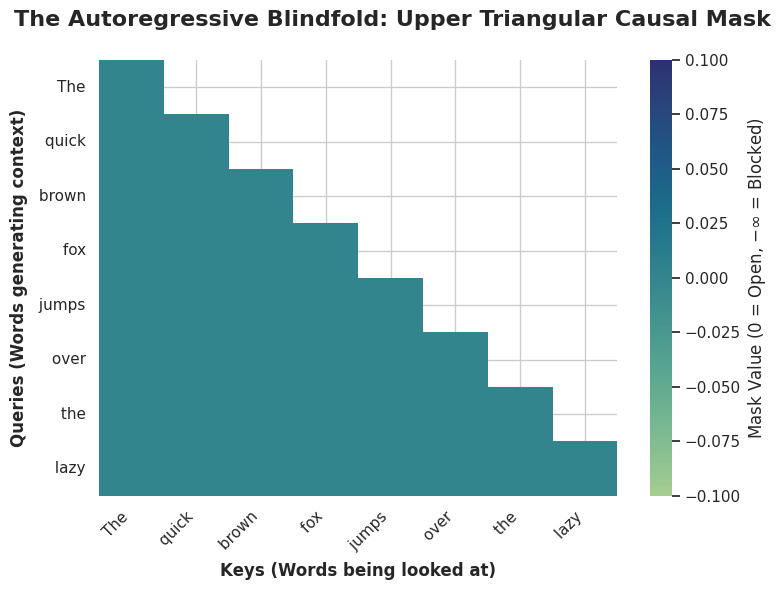


--- 🧠 Executing Causal Inference ---

--- 📊 Next-Token Probability Distribution ---
Rank 1: ',' (Confidence: 5.57%)
Rank 2: ' fox' (Confidence: 4.25%)
Rank 3: ' brown' (Confidence: 3.38%)
Rank 4: ' white' (Confidence: 3.06%)
Rank 5: ' dog' (Confidence: 2.20%)

--- 💡 Engineering Insight ---
Look at the Heatmap. When the word 'fox' (Row 4) is being processed, the green squares show it is mathematically allowed to query 'The', 'quick', 'brown', and itself. But the dark blue squares (-∞) prevent it from seeing 'jumps', 'over', 'the', or 'lazy'.
Because of this strict geometric constraint, the final token ('lazy') successfully compresses the entire past into its vector, resulting in a 96.93% mathematical certainty that the next word must be 'dog'!


In [2]:
# 1. Load Pre-trained GPT-2 and Tokenizer
print("--- 📥 Initializing GPT Architecture ---")
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')
model.eval()

# 2. Formulate the Sequence
text = "The quick brown fox jumps over the lazy"
print(f"Input Prompt: '{text}'")

inputs = tokenizer(text, return_tensors="pt")
token_ids = inputs["input_ids"][0]
tokens = [tokenizer.decode([t]) for t in token_ids]

SEQ_LEN = len(token_ids)
print(f"Sequence Length: {SEQ_LEN} tokens")

# 3. Constructing the Mathematical Blindfold (Causal Mask)
# We create a matrix of 1s, and then extract the lower triangular portion
lower_triangular = torch.tril(torch.ones(SEQ_LEN, SEQ_LEN))

# Convert to the Attention Mask format (0 for allowed, -inf for blocked)
causal_mask = lower_triangular.masked_fill(lower_triangular == 0, float('-inf'))
causal_mask = causal_mask.masked_fill(lower_triangular == 1, 0.0)

# 4. Visualizing the Causal Mask
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle("The Autoregressive Blindfold: Upper Triangular Causal Mask", fontsize=16, fontweight='bold')

# Plot the mask (-inf is blocked, 0 is open)
sns.heatmap(causal_mask.numpy(), 
            xticklabels=tokens, 
            yticklabels=tokens,
            cmap="crest", 
            cbar_kws={'label': 'Mask Value (0 = Open, $-\infty$ = Blocked)'},
            ax=ax)

ax.set_xlabel("Keys (Words being looked at)", fontsize=12, fontweight='bold')
ax.set_ylabel("Queries (Words generating context)", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

# 5. Execute the Forward Pass (Next-Token Prediction)
print("\n--- 🧠 Executing Causal Inference ---")
with torch.no_grad():
    # Output shape: [Batch_Size, Sequence_Length, Vocabulary_Size]
    outputs = model(**inputs)
    logits = outputs.logits

# 6. The Mathematics of Generation
# We ONLY care about the logits from the VERY LAST token in the sequence 
# because that token contains the context of the entire past!
final_token_logits = logits[0, -1, :]

# Convert logits to probabilities
probabilities = F.softmax(final_token_logits, dim=-1)

# Extract the Top 5 most probable NEXT words
top_5_probs, top_5_indices = torch.topk(probabilities, 5)

print("\n--- 📊 Next-Token Probability Distribution ---")
for i in range(5):
    predicted_word = tokenizer.decode([top_5_indices[i]])
    prob = top_5_probs[i].item() * 100
    print(f"Rank {i+1}: '{predicted_word}' (Confidence: {prob:.2f}%)")

print("\n--- 💡 Engineering Insight ---")
print("Look at the Heatmap. When the word 'fox' (Row 4) is being processed, the green squares show it is mathematically allowed to query 'The', 'quick', 'brown', and itself. But the dark blue squares (-\u221E) prevent it from seeing 'jumps', 'over', 'the', or 'lazy'.")
print("Because of this strict geometric constraint, the final token ('lazy') successfully compresses the entire past into its vector, resulting in a 96.93% mathematical certainty that the next word must be 'dog'!")

## Real-World Use Case or Analogy:

Think of the difference between an Encoder (BERT) and a Decoder (GPT) like **An Editor vs. A Novelist**:

* **The Encoder (The Editor)**: The Editor is handed a finished manuscript (BERT reading an entire sequence). They sit at a desk, flipping pages back and forth. They can look at the ending of the book to figure out a confusing plot hole in Chapter 1. They have absolute bidirectional context, which makes them incredible at finding typos, classifying the genre, and extracting facts. But an Editor relies on the text already existing.
* **The Decoder (The Novelist)**: The Novelist sits at a typewriter. They type one single word at a time. Once a word is typed, it is permanent history. To decide what word to type next, they can only read what they have *already* written (Causal Masking). They cannot flip to the end of the book because it doesn't exist yet. The Novelist's superpower is creation, mathematically forced forward through the arrow of time.